In [3]:
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt
import scanpy as sc

In [4]:
data = {
    "gene": sc.read_h5ad("results/h5ad_clustered/Blastocyst.gene_based.h5ad"),
    "transcript": sc.read_h5ad("results/h5ad_clustered/Blastocyst.transcript_based.h5ad"),
}

--------------------------------------------------------------------------------
Base: gene


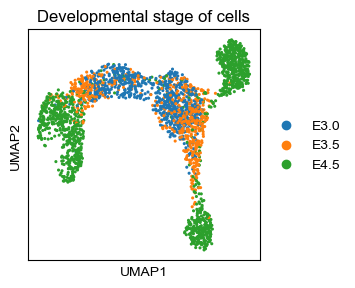

Cells: 2535
Counter({'E4.5': 1245, 'E3.0': 693, 'E3.5': 597})
--------------------------------------------------------------------------------
Base: transcript


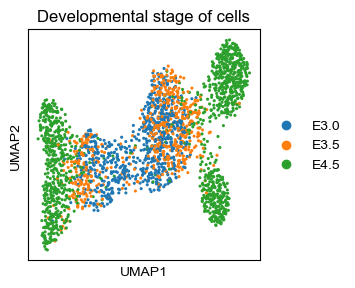

Cells: 2535
Counter({'E4.5': 1245, 'E3.0': 693, 'E3.5': 597})


In [10]:
for base, adata in data.items():
    print("-" * 80)
    print("Base:", base)
    d = {"Early": "E3.0", "Mid": "E3.5", "Late": "E4.5"}
    adata.obs["Stage_str"] = [d[x] for x in adata.obs["Stage"]]
    with plt.rc_context({"figure.figsize": (3, 3)}):
        sc.pl.umap(
            adata, 
            color="Stage_str", 
            palette={"E3.0": "C0", "E3.5": "C1", "E4.5": "C2"}, 
            size=20, 
            title="Developmental stage of cells", 
            save="_of_stage.%s_based.pdf" % base,
        )
    print("Cells:", len(adata))
    print(Counter(adata.obs["Stage_str"]))

--------------------------------------------------------------------------------
Base: gene


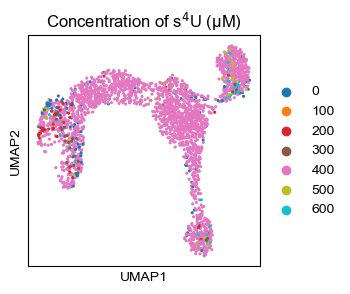

Cells: 2535
Counter({'400': 2236, '0': 146, '200': 40, '500': 39, '600': 32, '300': 32, '100': 10})
--------------------------------------------------------------------------------
Base: transcript


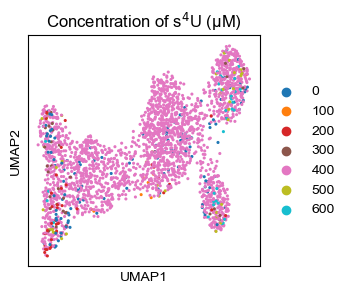

Cells: 2535
Counter({'400': 2236, '0': 146, '200': 40, '500': 39, '600': 32, '300': 32, '100': 10})


In [7]:
for base, adata in data.items():
    print("-" * 80)
    print("Base:", base)
    adata.obs["s4U_str"] = [str(x) for x in adata.obs["s4U"]]
    with plt.rc_context({"figure.figsize": (3, 3)}):
        sc.pl.umap(
            adata, 
            color="s4U_str", 
            palette="tab10", 
            size=20, 
            frameon=True, 
            title="Concentration of s$^4$U (μM)", 
            save="_of_s4u.%s_based.pdf" % base,
        )
    print("Cells:", len(adata))
    print(Counter(adata.obs["s4U_str"]))

--------------------------------------------------------------------------------
Base: gene


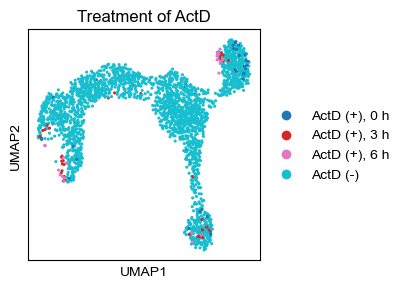

Cells: 2535
Counter({'ActD (-)': 2425, 'ActD (+), 0 h': 45, 'ActD (+), 3 h': 38, 'ActD (+), 6 h': 27})
--------------------------------------------------------------------------------
Base: transcript


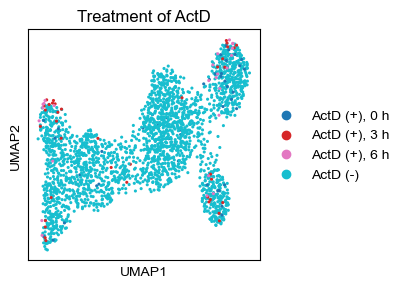

Cells: 2535
Counter({'ActD (-)': 2425, 'ActD (+), 0 h': 45, 'ActD (+), 3 h': 38, 'ActD (+), 6 h': 27})


In [8]:
for base, adata in data.items():
    print("-" * 80)
    print("Base:", base)
    vs = []
    for x in adata.obs["ActD"]:
        if np.isnan(x):
            vs.append("ActD (-)")
        else:
            vs.append("ActD (+), %d h" % x)
    adata.obs["ActD_str"] = vs
    with plt.rc_context({"figure.figsize": (3, 3)}):
        sc.pl.umap(
            adata, 
            color="ActD_str", 
            palette="tab10", 
            size=20, 
            frameon=True, 
            title="Treatment of ActD", 
            save="_of_actd.%s_based.pdf" % base,
        )
    print("Cells:", len(adata))
    print(Counter(adata.obs["ActD_str"]))

--------------------------------------------------------------------------------
Base: gene


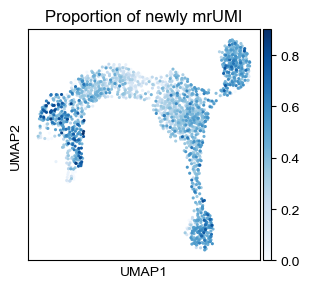

Cells: 2136
--------------------------------------------------------------------------------
Base: transcript


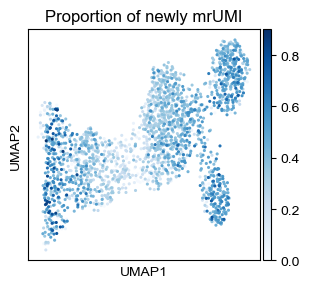

Cells: 2136


In [9]:
for base, adata in data.items():
    print("-" * 80)
    print("Base:", base)
    adata1 = adata[(adata.obs["s4U"] == 400) & (adata.obs["ActD"].isna())]
    with plt.rc_context({"figure.figsize": (3.3, 3)}):
        sc.pl.umap(
            adata1, 
            color="mrUMIs.New.Ratio", 
            color_map="Blues", 
            size=20, 
            frameon=True, 
            title="Proportion of newly mrUMI", 
            save="_of_new_mrumi.%s_based.pdf" % base, 
            vmin=0, 
            vmax=0.9,
        )
    print("Cells:", len(adata1))